In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from sklearn.datasets import make_classification
from IPython.display import display

# 1. Generate a synthetic 2D dataset to visualize the math clearly
X_vis, y_vis = make_classification(
    n_samples=200, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)

# 2. Define the function that draws the graph based on your slider inputs
def plot_decision_boundary(w1, w2, b):
    plt.figure(figsize=(10, 6))

    # Plot the two classes (Rock vs Mine)
    plt.scatter(X_vis[y_vis == 0][:, 0], X_vis[y_vis == 0][:, 1], color='blue', label='Class 0 (Rock)', edgecolors='k', s=60)
    plt.scatter(X_vis[y_vis == 1][:, 0], X_vis[y_vis == 1][:, 1], color='orange', label='Class 1 (Mine)', edgecolors='k', s=60)

    # Create a background grid to show the prediction zones
    x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
    y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))

    # The Logistic Regression formula: z = w1*x1 + w2*x2 + b
    Z = w1 * xx + w2 * yy + b
    # If Z > 0, predict Class 1, else predict Class 0
    Z_pred = (Z > 0).astype(int)

    # Color the background based on the math
    plt.contourf(xx, yy, Z_pred, alpha=0.2, levels=[-1, 0, 1], colors=['blue', 'orange'])

    # Draw the actual boundary line where the math equals exactly 0
    if w2 != 0:
        x_vals = np.array([x_min, x_max])
        # Solved for y: w1*x + w2*y + b = 0 -> y = -(w1*x + b)/w2
        y_vals = -(w1 * x_vals + b) / w2
        plt.plot(x_vals, y_vals, 'k--', lw=2, label='Decision Boundary ($w_1x_1 + w_2x_2 + b = 0$)')

    # Format the graph
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.title("Interactive Logistic Regression Boundary", fontsize=14, fontweight='bold')
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.show()

# 3. Create the interactive sliders
print("Adjust the sliders below to manually shift the decision boundary:")
widgets.interact(
    plot_decision_boundary,
    w1=widgets.FloatSlider(value=1.5, min=-5.0, max=5.0, step=0.1, description='Horizontal Influence'),
    w2=widgets.FloatSlider(value=-1.0, min=-5.0, max=5.0, step=0.1, description='Vertical Influence'),
    b=widgets.FloatSlider(value=0.5, min=-5.0, max=5.0, step=0.1, description='Decision Offset')
);

Adjust the sliders below to manually shift the decision boundary:


interactive(children=(FloatSlider(value=1.5, description='Horizontal Influence', max=5.0, min=-5.0), FloatSlid…

### Correlation Heatmap for SONAR Dataset

To understand the impact of features, let's visualize the correlation between all features and the target variable using a heatmap. First, we need to reload the SONAR dataset.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the URL for the dataset (as it was previously used)
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv'

# Load the dataset
sonar_data = pd.read_csv(url, header=None)

# The last column is the target variable (R for Rock, M for Mine)
# Let's convert it to a numerical format for correlation calculation (e.g., 0 for R, 1 for M)
sonar_data[60] = sonar_data[60].map({'R': 0, 'M': 1})

# Display the first few rows and information about the dataset
print("SONAR Dataset Head:")
display(sonar_data.head())
print("\nSONAR Dataset Info:")
sonar_data.info()

SONAR Dataset Head:


,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,0
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,0
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,0
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,0
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,0



SONAR Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       208 non-null    float64
 1   1       208 non-null    float64
 2   2       208 non-null    float64
 3   3       208 non-null    float64
 4   4       208 non-null    float64
 5   5       208 non-null    float64
 6   6       208 non-null    float64
 7   7       208 non-null    float64
 8   8       208 non-null    float64
 9   9       208 non-null    float64
 10  10      208 non-null    float64
 11  11      208 non-null    float64
 12  12      208 non-null    float64
 13  13      208 non-null    float64
 14  14      208 non-null    float64
 15  15      208 non-null    float64
 16  16      208 non-null    float64
 17  17      208 non-null    float64
 18  18      208 non-null    float64
 19  19      208 non-null    float64
 20  20      208 non-null    float64
 21  21      208 non-nu

Now, let's calculate the correlation matrix for the entire dataset and visualize it using a heatmap. This will help us identify which features are most strongly correlated with the target variable (column 60).

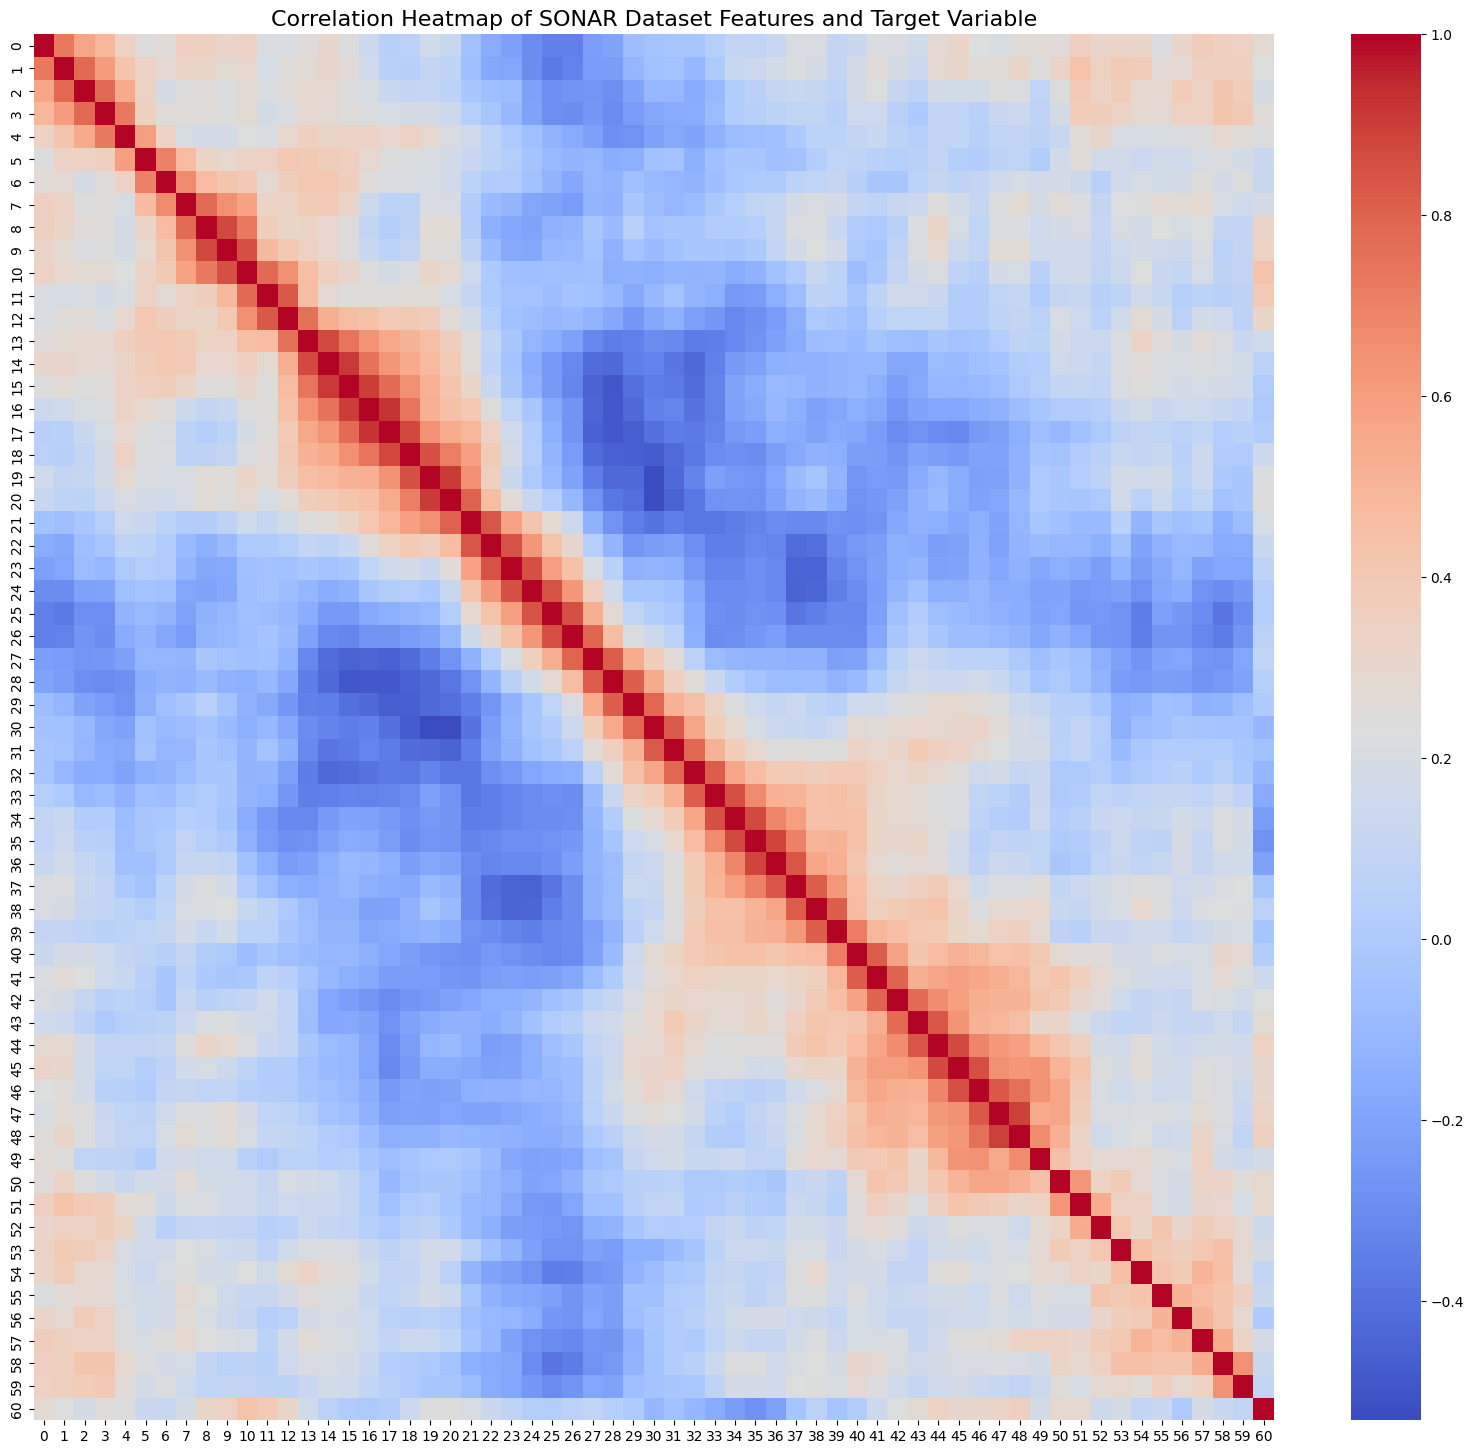

In [3]:
# Calculate the correlation matrix
correlation_matrix = sonar_data.corr()

# Plotting the heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of SONAR Dataset Features and Target Variable', fontsize=16)
plt.show()